In [14]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans


In [ ]:
DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

IMAGE_PATH = DATA_DIR / "images.jpeg"

assert IMAGE_PATH.exists(), (
    f"Image not found at {IMAGE_PATH.resolve()}. "
    "Put an image in the data/ folder or update IMAGE_PATH."
)


Size: (161, 161), Format: None, Mode: RGB


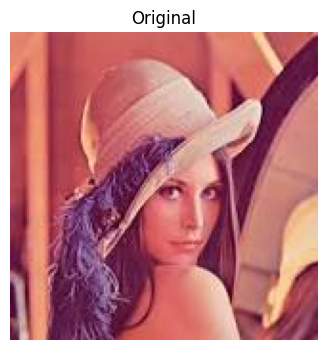

In [16]:
img = Image.open(IMAGE_PATH).convert("RGB")

print(f"Size: {img.size}, Format: {img.format}, Mode: {img.mode}")

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title("Original")
plt.show()


## Prepare Pixel Data

**Fix:** the original notebook clustered the raw `uint8` pixel array
directly. `KMeans`'s internal distance math (`a @ b`) can overflow an 8-bit
integer type, which is exactly the `RuntimeWarning: overflow encountered in
matmul` you saw. Casting to `float64` before clustering fixes it.

In [17]:
image_array = np.array(img)
pixels = image_array.reshape(-1, 3).astype(np.float64)

print("Pixel matrix shape:", pixels.shape)


Pixel matrix shape: (25921, 3)


In [ ]:
def compress_image(image_array: np.ndarray, n_colors: int, random_state: int = 42):
    h, w, c = image_array.shape
    pixels = image_array.reshape(-1, c).astype(np.float64)

    kmeans = KMeans(n_clusters=n_colors, random_state=random_state, n_init=10)
    labels = kmeans.fit_predict(pixels)

    palette = kmeans.cluster_centers_.astype(np.uint8)
    quantized = palette[labels].reshape(h, w, c).astype(np.uint8)

    return quantized, kmeans


/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_

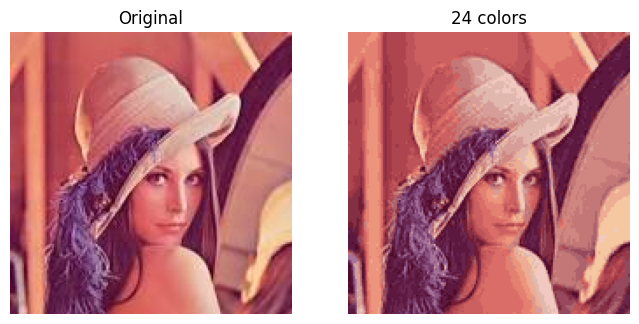

In [19]:
quantized_24, kmeans_24 = compress_image(image_array, n_colors=24)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image_array)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(quantized_24)
axes[1].set_title("24 colors")
axes[1].axis("off")
plt.show()


## Measure Quality: PSNR

Visual comparison alone doesn't tell you *how much* quality was lost.
**PSNR** (Peak Signal-to-Noise Ratio) is a standard metric for this — higher
is better/closer to the original. This gives you a number to report instead
of just "looks fine.".

In [20]:
def psnr(original: np.ndarray, compressed: np.ndarray) -> float:
    mse = np.mean((original.astype(np.float64) - compressed.astype(np.float64)) ** 2)
    if mse == 0:
        return float("inf")
    return 20 * np.log10(255.0) - 10 * np.log10(mse)


print(f"PSNR (24 colors): {psnr(image_array, quantized_24):.2f} dB")


PSNR (24 colors): 30.71 dB


/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_

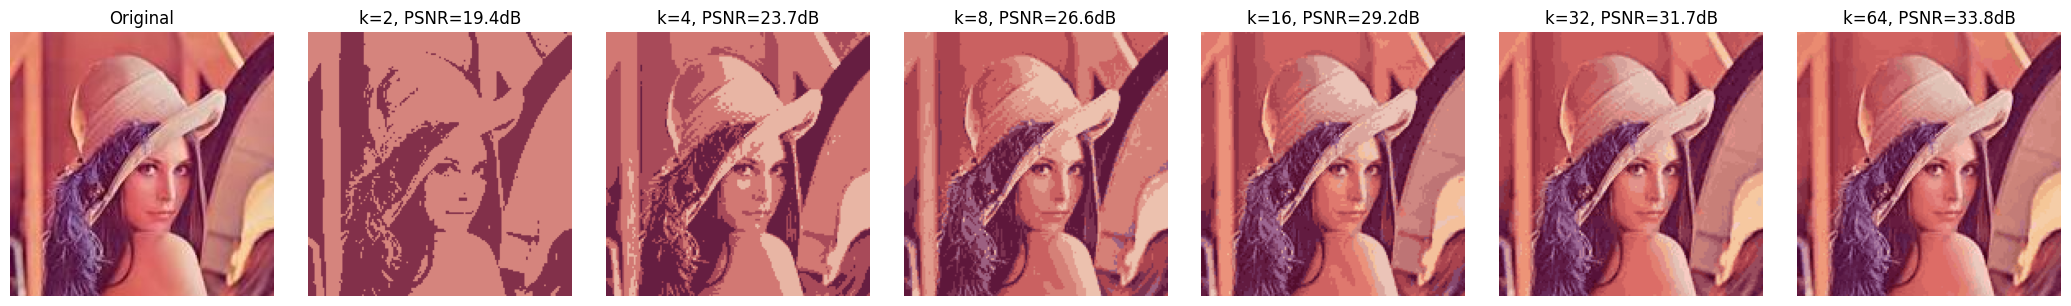

In [21]:
k_values = [2, 4, 8, 16, 32, 64]
results = {}

fig, axes = plt.subplots(1, len(k_values) + 1, figsize=(3 * (len(k_values) + 1), 3))

axes[0].imshow(image_array)
axes[0].set_title("Original")
axes[0].axis("off")

for ax, k in zip(axes[1:], k_values):
    quantized, model = compress_image(image_array, n_colors=k)
    results[k] = {"image": quantized, "model": model, "psnr": psnr(image_array, quantized)}

    ax.imshow(quantized)
    ax.set_title(f"k={k}, PSNR={results[k]['psnr']:.1f}dB")
    ax.axis("off")

plt.tight_layout()
plt.show()


## Elbow Method

Helps justify a specific choice of *k* quantitatively rather than picking a
number arbitrarily: plot K-Means inertia (within-cluster variance) against
*k* and look for the "elbow" where returns diminish.

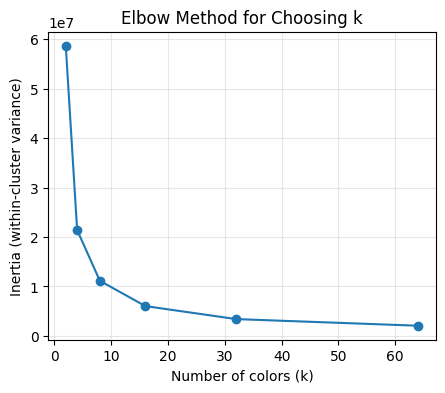

In [22]:
inertias = [results[k]["model"].inertia_ for k in k_values]

plt.figure(figsize=(5, 4))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of colors (k)")
plt.ylabel("Inertia (within-cluster variance)")
plt.title("Elbow Method for Choosing k")
plt.grid(alpha=0.3)
plt.show()


In [23]:
original_size = IMAGE_PATH.stat().st_size
print(f"Original file size: {original_size / 1024:.1f} KB\n")

summary = []
for k in k_values:
    out_path = OUTPUT_DIR / f"quantized_k{k}.png"
    Image.fromarray(results[k]["image"]).save(out_path, optimize=True)
    size = out_path.stat().st_size
    ratio = original_size / size
    summary.append((k, results[k]["psnr"], size / 1024, ratio))
    print(f"k={k:>3} | PSNR={results[k]['psnr']:6.2f} dB | "
          f"size={size/1024:7.1f} KB | ratio={ratio:.2f}x")


Original file size: 5.7 KB

k=  2 | PSNR= 19.35 dB | size=    2.3 KB | ratio=2.47x
k=  4 | PSNR= 23.73 dB | size=    5.2 KB | ratio=1.11x
k=  8 | PSNR= 26.56 dB | size=    9.3 KB | ratio=0.62x
k= 16 | PSNR= 29.21 dB | size=   14.2 KB | ratio=0.40x
k= 32 | PSNR= 31.68 dB | size=   20.2 KB | ratio=0.28x
k= 64 | PSNR= 33.83 dB | size=   26.4 KB | ratio=0.22x


## Summary Table

In [24]:
import pandas as pd

df = pd.DataFrame(summary, columns=["k (colors)", "PSNR (dB)", "Size (KB)", "Compression ratio"])
df


,k (colors),PSNR (dB),Size (KB),Compression ratio
0,2,19.352224,2.320312,2.473906
1,4,23.727464,5.167969,1.110733
2,8,26.558152,9.261719,0.619781
3,16,29.212774,14.248047,0.402879
4,32,31.680141,20.190430,0.284305
5,64,33.831972,26.435547,0.217141
